In [ ]:
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

%config InlineBackend.figure_format = 'retina'

np.random.seed(42)
print("✅ Библиотеки загружены, визуализация настроена.")

✅ Библиотеки загружены, визуализация настроена.


In [ ]:
# ГЕНЕРАЦИЯ ДАННЫХ
dist_params = {
    'Бинарная метрика (1/0) | p=0.3': lambda n: np.random.binomial(1, 0.3, n),
    'Нормальная (Непрерывная) | mu=10, std=2': lambda n: np.random.normal(10, 2, n),
    'Экспоненциальная (Скошенная) | scale=5': lambda n: np.random.exponential(5, n)
}
print("✅ Генераторы распределений готовы.")

✅ Генераторы распределений готовы.


In [ ]:
# ПОСТРОЕНИЕ ГРАФИКОВ СИМУЛЯЦИИ
def run_aa_simulations(n_A, n_B, n_sims=15000, alpha=0.05):
    """
    Проводит A/A симуляцию и строит гистограммы p-value + ECDF графики.
    """
    fig, axes = plt.subplots(3, 2, figsize=(14, 15))

    for i, (name, gen_func) in enumerate(dist_params.items()):
        p_values = []

        # Цикл Монте-Карло
        for _ in range(n_sims):
            A = gen_func(n_A)
            B = gen_func(n_B)

            # T-test Уэлча (equal_var=False)
            _, p_val = stats.ttest_ind(A, B, equal_var=False)
            p_values.append(p_val)

        p_values = np.array(p_values)

        # Расчет FPR (ошибка 1-го рода)
        fpr = np.mean(p_values < alpha)

        #  Гистограмма p-value
        sns.histplot(p_values, bins=20, stat='density', ax=axes[i, 0], color='#4C72B0', alpha=0.7)
        axes[i, 0].axhline(1, color='#C44E52', linestyle='--', linewidth=2, label='Идеал U(0,1)')
        axes[i, 0].set_title(f'{name}\nFPR: {fpr:.4f} (Ожидаем ~{alpha})', fontsize=12, fontweight='bold')
        axes[i, 0].set_xlabel('Значение p-value')
        axes[i, 0].set_ylabel('Плотность')
        axes[i, 0].legend()

        #  ECDF график
        x = np.sort(p_values)
        y = np.arange(1, len(x) + 1) / len(x)
        axes[i, 1].plot(x, y, marker='.', linestyle='none', color='#55A868', alpha=0.5)
        axes[i, 1].plot([0, 1], [0, 1], color='#C44E52', linestyle='--', linewidth=2, label='Идеал (y=x)')
        axes[i, 1].set_title(f'{name} | ECDF График', fontsize=12, fontweight='bold')
        axes[i, 1].set_xlabel('Теоретические квантили U(0,1)')
        axes[i, 1].set_ylabel('Эмпирическая вероятность')
        axes[i, 1].legend()

    plt.suptitle(f'Симуляция А/А теста | Выборки: Группа А = {n_A}, Группа Б = {n_B}',
                 fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()
print('Функция загружена')


Функция загружена


📊 Результаты для сплита 50/50:


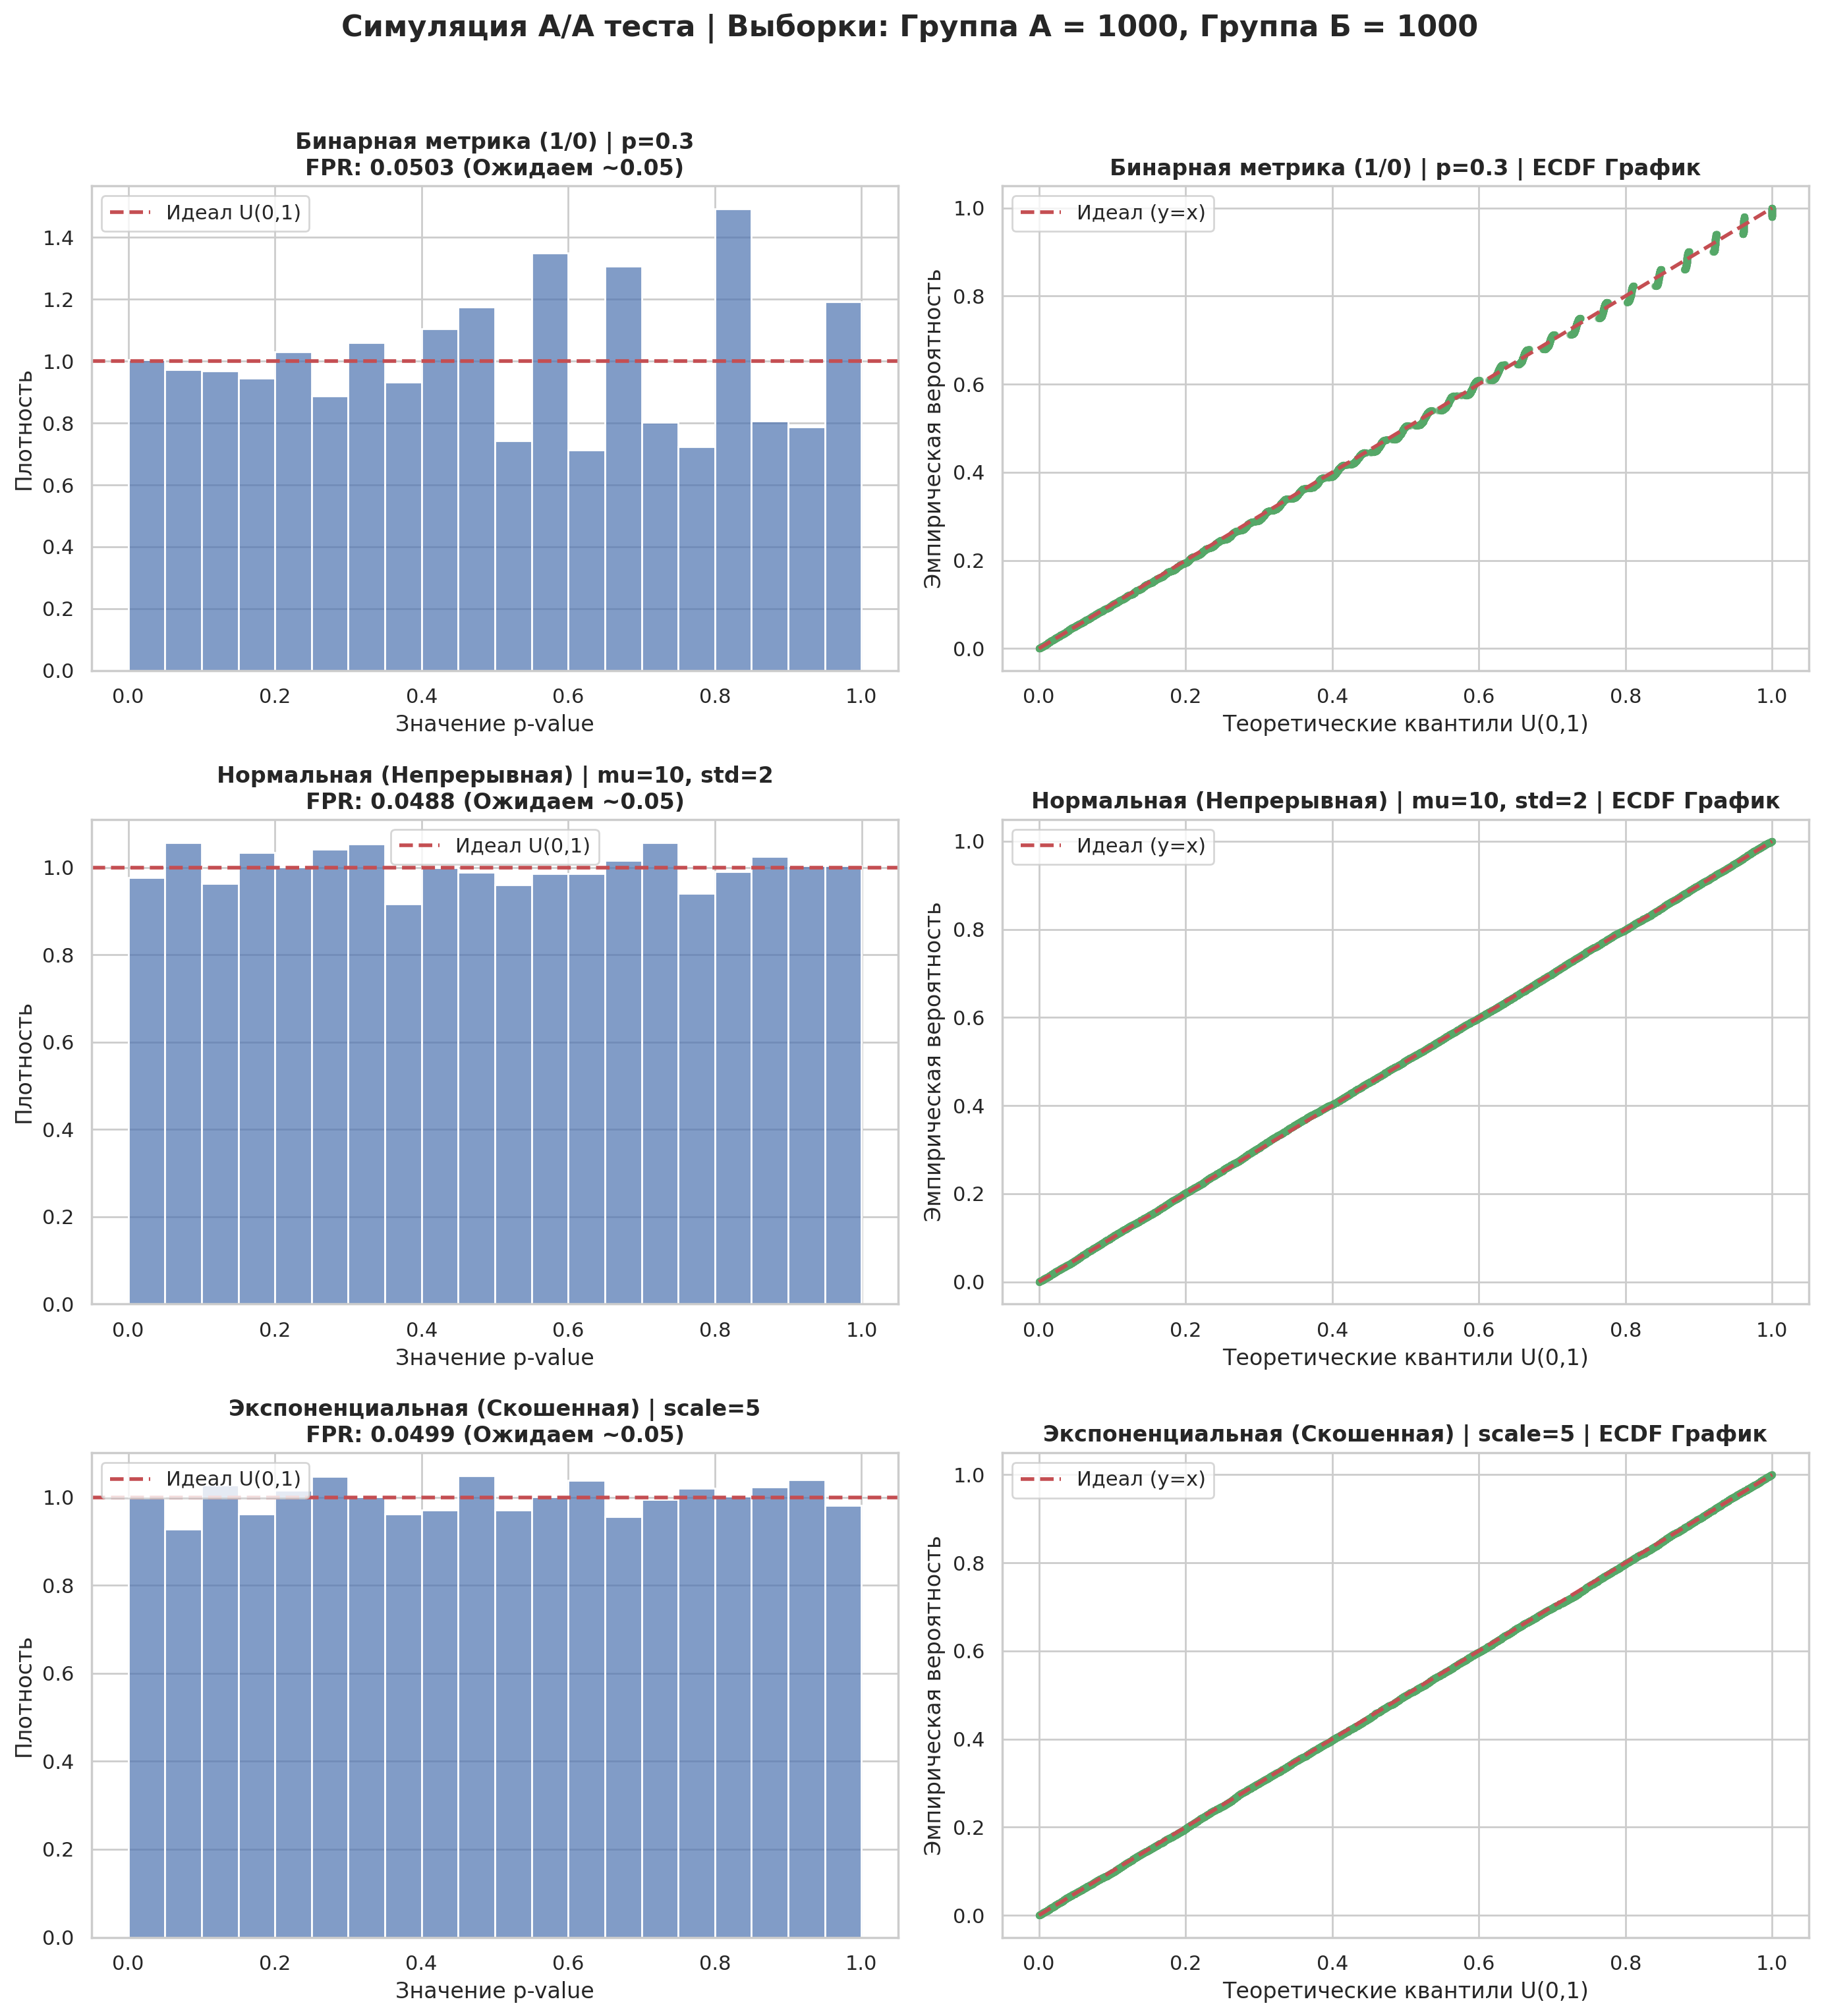


📊 Результаты для сплита 10/90 (дисбаланс):


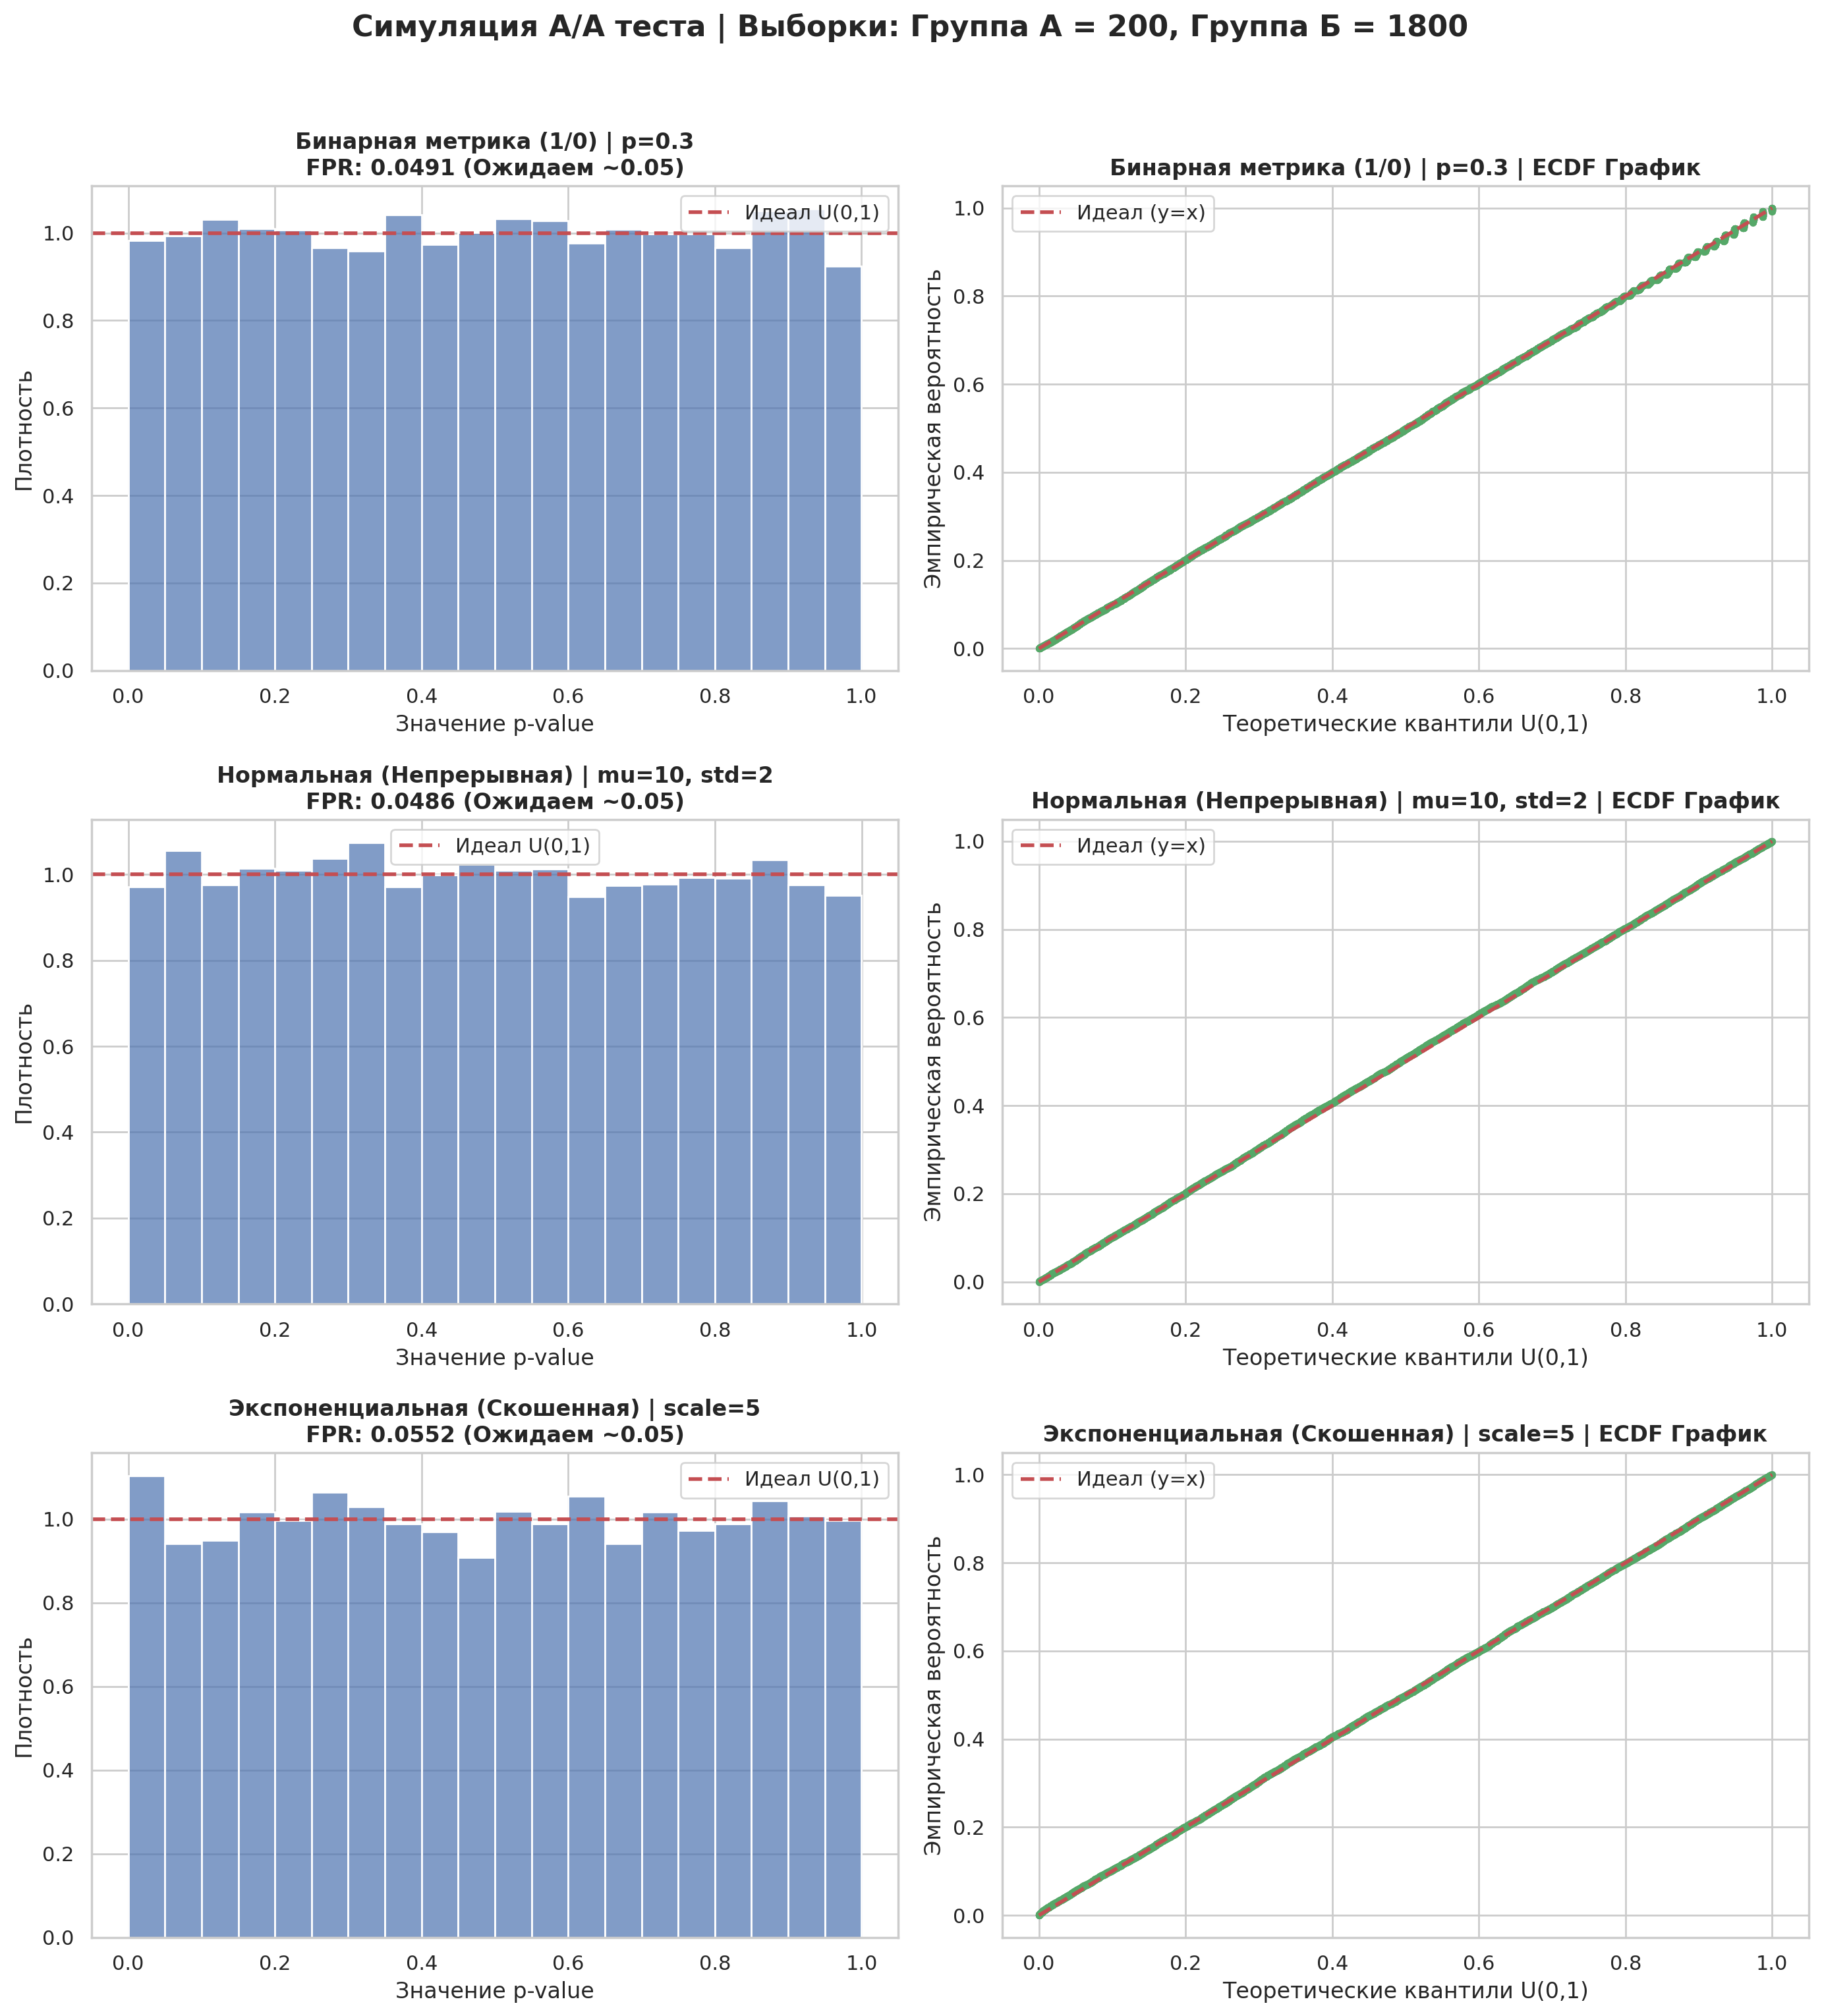

In [ ]:
print("📊 Результаты для сплита 50/50:")
run_aa_simulations(n_A=1000, n_B=1000)

print("\n📊 Результаты для сплита 10/90 (дисбаланс):")
run_aa_simulations(n_A=200, n_B=1800)

In [ ]:
from statsmodels.stats.power import TTestIndPower
from statsmodels.stats.proportion import proportion_effectsize

# Инициализируем калькулятор мощности для T-теста
power_calc = TTestIndPower()

print("✅ Инструменты statsmodels для А/В тестов загружены.")

✅ Инструменты statsmodels для А/В тестов загружены.


⏳ Симулируем падение ошибки 2-го рода при росте выборки...
⏳ Симулируем рост ошибки 2-го рода при увеличении дисперсии...


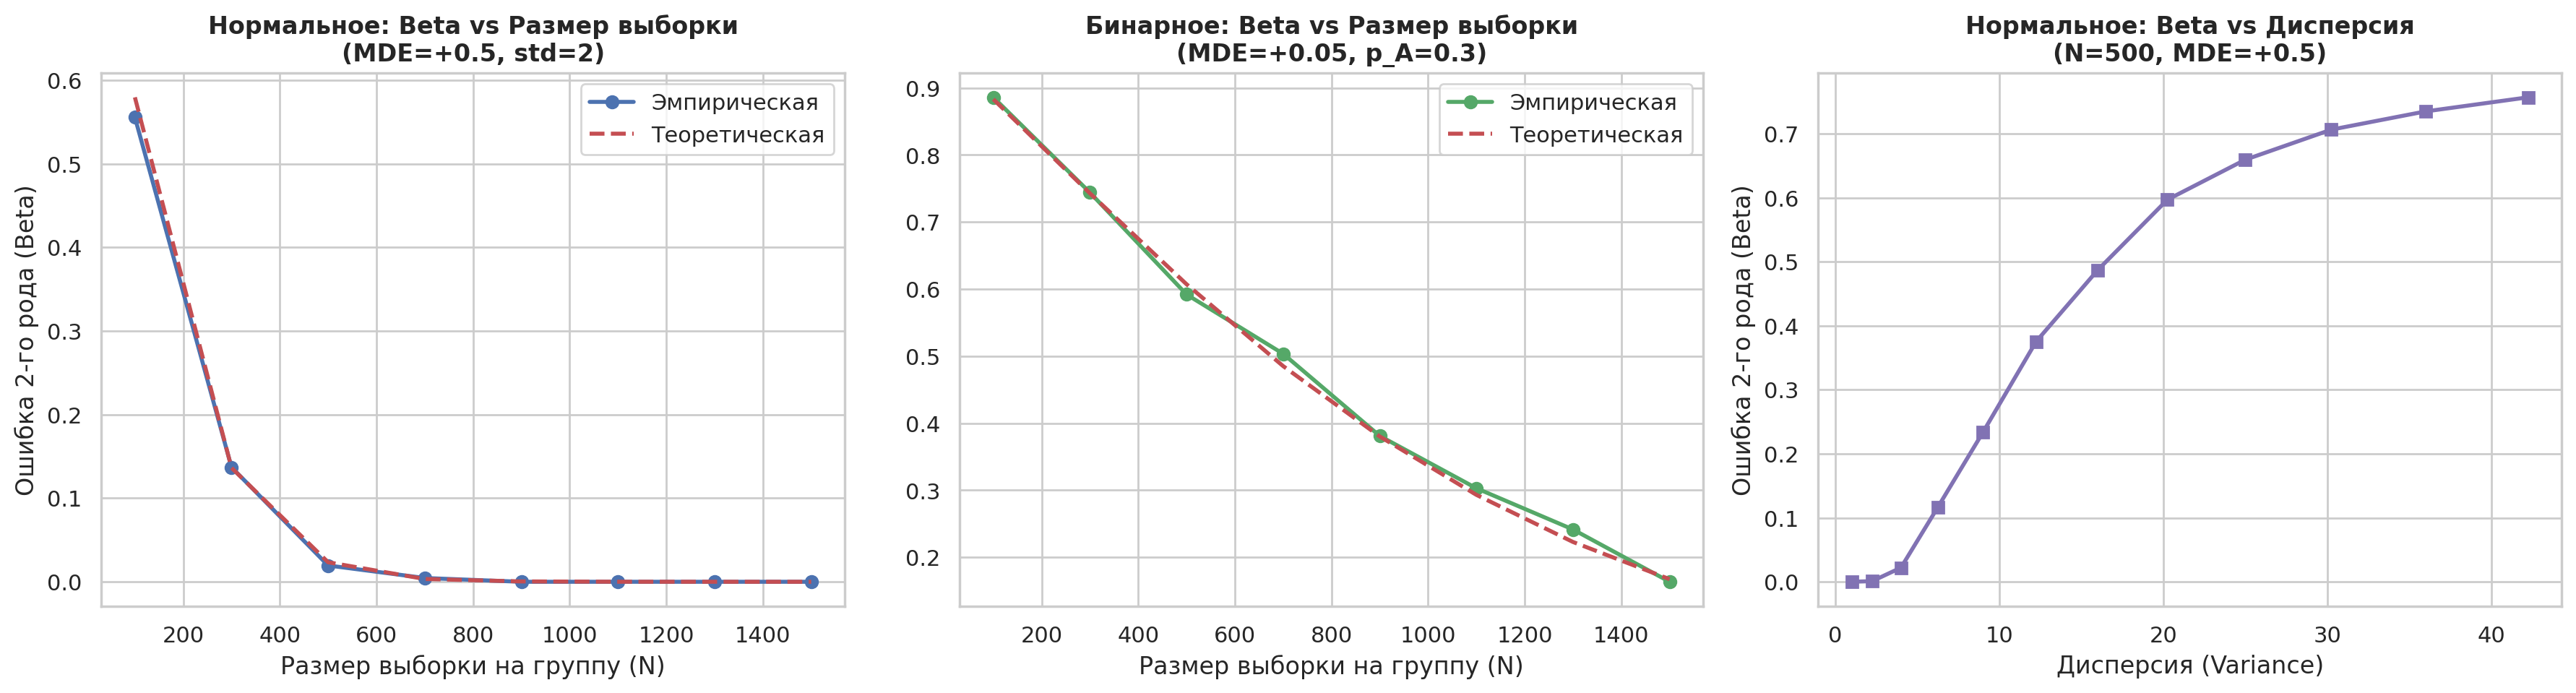

In [ ]:
# Параметры симуляции
n_sims_ab = 2000
alpha = 0.05
sample_sizes = np.arange(100, 1601, 200) # Выборки от 100 до 1600
std_devs = np.arange(1.0, 7.0, 0.5)      # Рост стандартного отклонения (шума)

# Зависимость Beta от размера выборки (N)
beta_norm_emp, beta_norm_theor = [], []
beta_bin_emp, beta_bin_theor = [], []

# Фиксированный эффект (MDE)
# Нормальное: базовое среднее = 10, эффект = +0.5 (новое среднее = 10.5), std = 2
# Бинарное: базовая конверсия = 0.3, эффект = +0.05 (новая конверсия = 0.35)

print("⏳ Симулируем падение ошибки 2-го рода при росте выборки...")
for n in sample_sizes:
    # --- Нормальное распределение ---
    p_vals_n = [stats.ttest_ind(np.random.normal(10, 2, n),
                                np.random.normal(10.5, 2, n),
                                equal_var=False)[1] for _ in range(n_sims_ab)]
    # Эмпирическая бета (не отклонили H0, хотя эффект есть: p >= alpha)
    beta_norm_emp.append(np.mean(np.array(p_vals_n) >= alpha))

    # Теоретическая бета
    effect_size_norm = 0.5 / 2  # Cohen's d: (10.5 - 10) / 2
    power_norm = power_calc.solve_power(effect_size=effect_size_norm, nobs1=n, alpha=alpha, ratio=1.0)
    beta_norm_theor.append(1 - power_norm)

    # --- Бинарное распределение ---
    p_vals_b = [stats.ttest_ind(np.random.binomial(1, 0.3, n),
                                np.random.binomial(1, 0.35, n),
                                equal_var=False)[1] for _ in range(n_sims_ab)]
    beta_bin_emp.append(np.mean(np.array(p_vals_b) >= alpha))

    # Теоретическая бета для пропорций
    effect_size_bin = proportion_effectsize(0.35, 0.3)
    power_bin = power_calc.solve_power(effect_size=effect_size_bin, nobs1=n, alpha=alpha, ratio=1.0)
    beta_bin_theor.append(1 - power_bin)

# Зависимость Beta от роста дисперсии (при фиксированном N=500 и эффекте +0.5)
beta_var_emp = []
fixed_n = 500

print("⏳ Симулируем рост ошибки 2-го рода при увеличении дисперсии...")
for std in std_devs:
    p_vals_v = [stats.ttest_ind(np.random.normal(10, std, fixed_n),
                                np.random.normal(10.5, std, fixed_n),
                                equal_var=False)[1] for _ in range(n_sims_ab)]
    beta_var_emp.append(np.mean(np.array(p_vals_v) >= alpha))

# --- ОТРИСОВКА ГРАФИКОВ ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

#  Beta vs N (Нормальное)
axes[0].plot(sample_sizes, beta_norm_emp, marker='o', linewidth=2, label='Эмпирическая')
axes[0].plot(sample_sizes, beta_norm_theor, linestyle='--', color='#C44E52', linewidth=2, label='Теоретическая')
axes[0].set_title('Нормальное: Beta vs Размер выборки\n(MDE=+0.5, std=2)', fontweight='bold')
axes[0].set_xlabel('Размер выборки на группу (N)')
axes[0].set_ylabel('Ошибка 2-го рода (Beta)')
axes[0].legend()

#  Beta vs N(Бинарное)
axes[1].plot(sample_sizes, beta_bin_emp, marker='o', color='#55A868', linewidth=2, label='Эмпирическая')
axes[1].plot(sample_sizes, beta_bin_theor, linestyle='--', color='#C44E52', linewidth=2, label='Теоретическая')
axes[1].set_title('Бинарное: Beta vs Размер выборки\n(MDE=+0.05, p_A=0.3)', fontweight='bold')
axes[1].set_xlabel('Размер выборки на группу (N)')
axes[1].legend()

#  Beta vs Дисперсия (Нормальное)
variances = std_devs ** 2
axes[2].plot(variances, beta_var_emp, marker='s', color='#8172B3', linewidth=2)
axes[2].set_title('Нормальное: Beta vs Дисперсия\n(N=500, MDE=+0.5)', fontweight='bold')
axes[2].set_xlabel('Дисперсия (Variance)')
axes[2].set_ylabel('Ошибка 2-го рода (Beta)')

plt.tight_layout()
plt.show()

🎯 Вычисленный идеальный размер выборки: 253 пользователей на группу


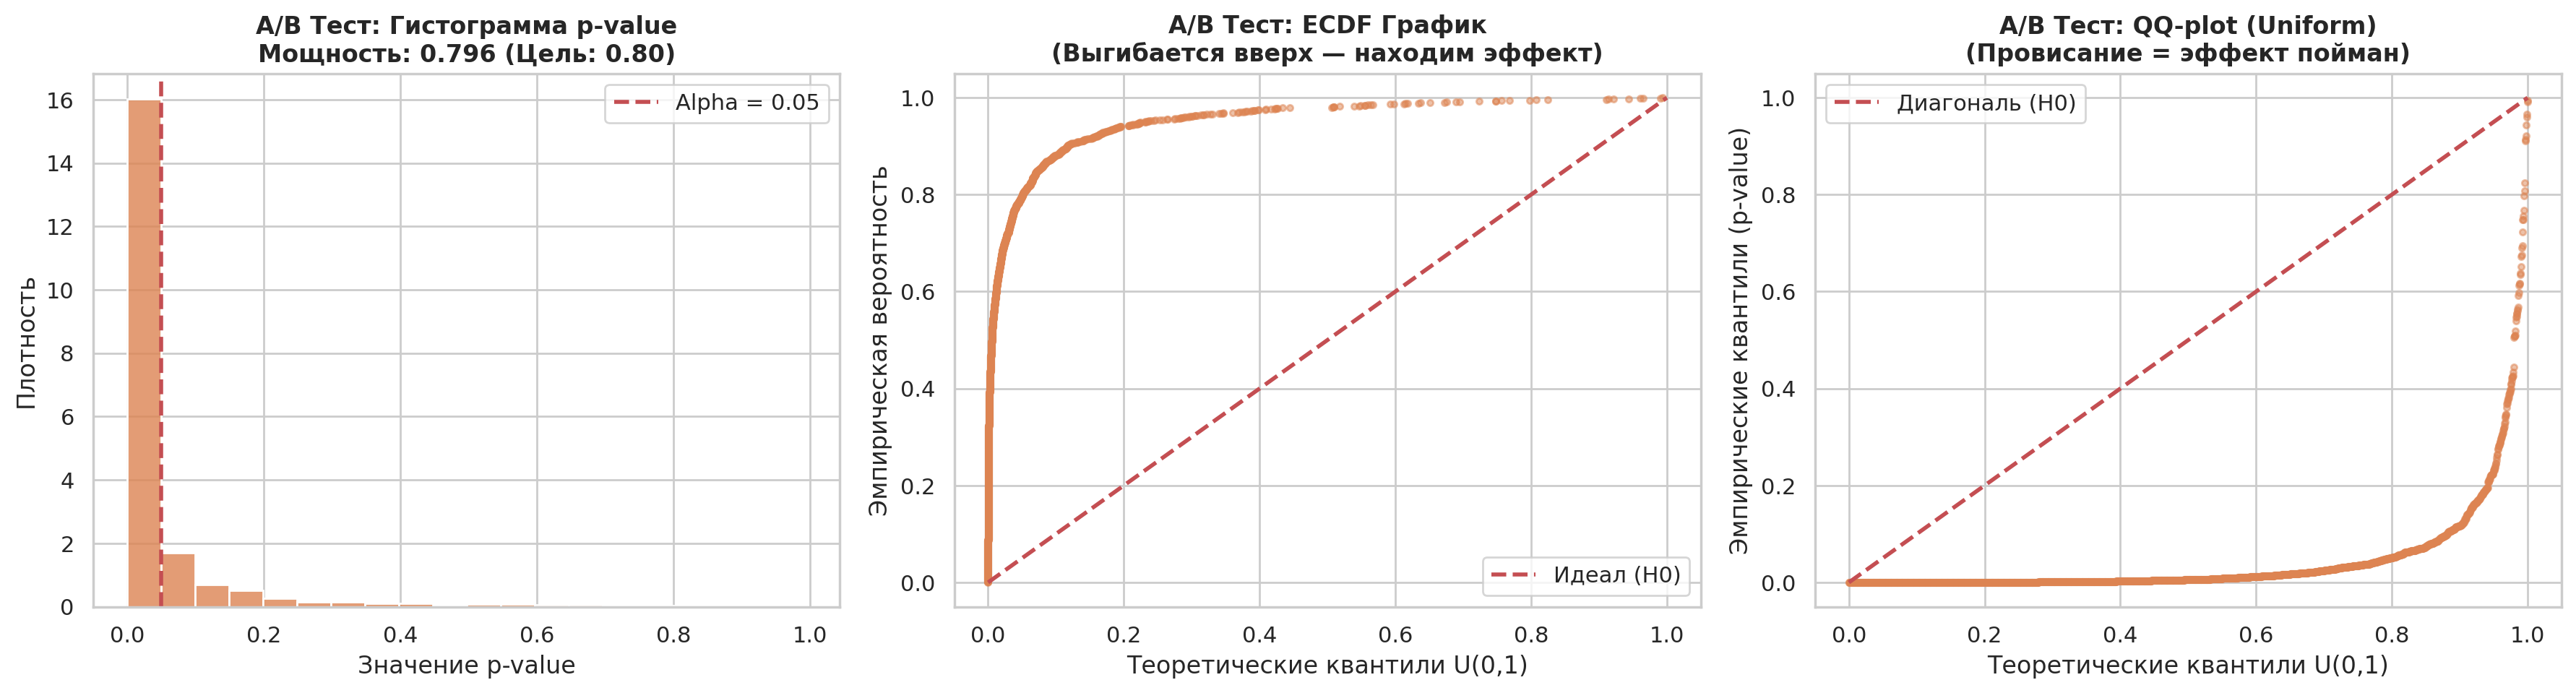

In [ ]:
# Считаем необходимый размер выборки для нормального распределения
target_power = 0.8
effect_size = 0.5 / 2

required_n = int(np.ceil(power_calc.solve_power(effect_size=effect_size, power=target_power, alpha=alpha, ratio=1.0)))
print(f"🎯 Вычисленный идеальный размер выборки: {required_n} пользователей на группу")

# Симуляция Монте-Карло с этим конкретным размером
p_vals_ideal = []
for _ in range(n_sims_ab):
    A = np.random.normal(10, 2, required_n)
    B = np.random.normal(10.5, 2, required_n) # Заложен истинный эффект: +0.5
    _, p_val = stats.ttest_ind(A, B, equal_var=False)
    p_vals_ideal.append(p_val)

p_vals_ideal = np.array(p_vals_ideal)
actual_power = np.mean(p_vals_ideal < alpha)

# Визуализация: Гистограмма, ECDF и QQ-plot
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# График 1: Гистограмма p-value ---
sns.histplot(p_vals_ideal, bins=20, stat='density', ax=axes[0], color='#DD8452', alpha=0.8)
axes[0].axvline(alpha, color='#C44E52', linestyle='--', linewidth=2, label=f'Alpha = {alpha}')
axes[0].set_title(f'А/В Тест: Гистограмма p-value\nМощность: {actual_power:.3f} (Цель: 0.80)', fontweight='bold')
axes[0].set_xlabel('Значение p-value')
axes[0].set_ylabel('Плотность')
axes[0].legend()

# График 2: ECDF ---
x_ecdf = np.sort(p_vals_ideal)
y_ecdf = np.arange(1, len(x_ecdf) + 1) / len(x_ecdf)
axes[1].plot(x_ecdf, y_ecdf, marker='.', linestyle='none', color='#DD8452', alpha=0.5)
axes[1].plot([0, 1], [0, 1], color='#C44E52', linestyle='--', linewidth=2, label='Идеал (H0)')
axes[1].set_title('А/В Тест: ECDF График\n(Выгибается вверх — находим эффект)', fontweight='bold')
axes[1].set_xlabel('Теоретические квантили U(0,1)')
axes[1].set_ylabel('Эмпирическая вероятность')
axes[1].legend()

# График 3: Ручной QQ-plot для p-value ---
# Теоретические квантили равномерного распределения от 0 до 1
theoretical_q = np.linspace(0, 1, len(p_vals_ideal))
# Эмпирические квантили — это просто отсортированные p-value
observed_q = np.sort(p_vals_ideal)

axes[2].scatter(theoretical_q, observed_q, color='#DD8452', alpha=0.5, marker='.')
axes[2].plot([0, 1], [0, 1], color='#C44E52', linestyle='--', linewidth=2, label='Диагональ (H0)')
axes[2].set_title('А/В Тест: QQ-plot (Uniform)\n(Провисание = эффект пойман)', fontweight='bold')
axes[2].set_xlabel('Теоретические квантили U(0,1)')
axes[2].set_ylabel('Эмпирические квантили (p-value)')
axes[2].legend()

plt.tight_layout()
plt.show()

⏳ Сэмплируем данные через Бутстрап...


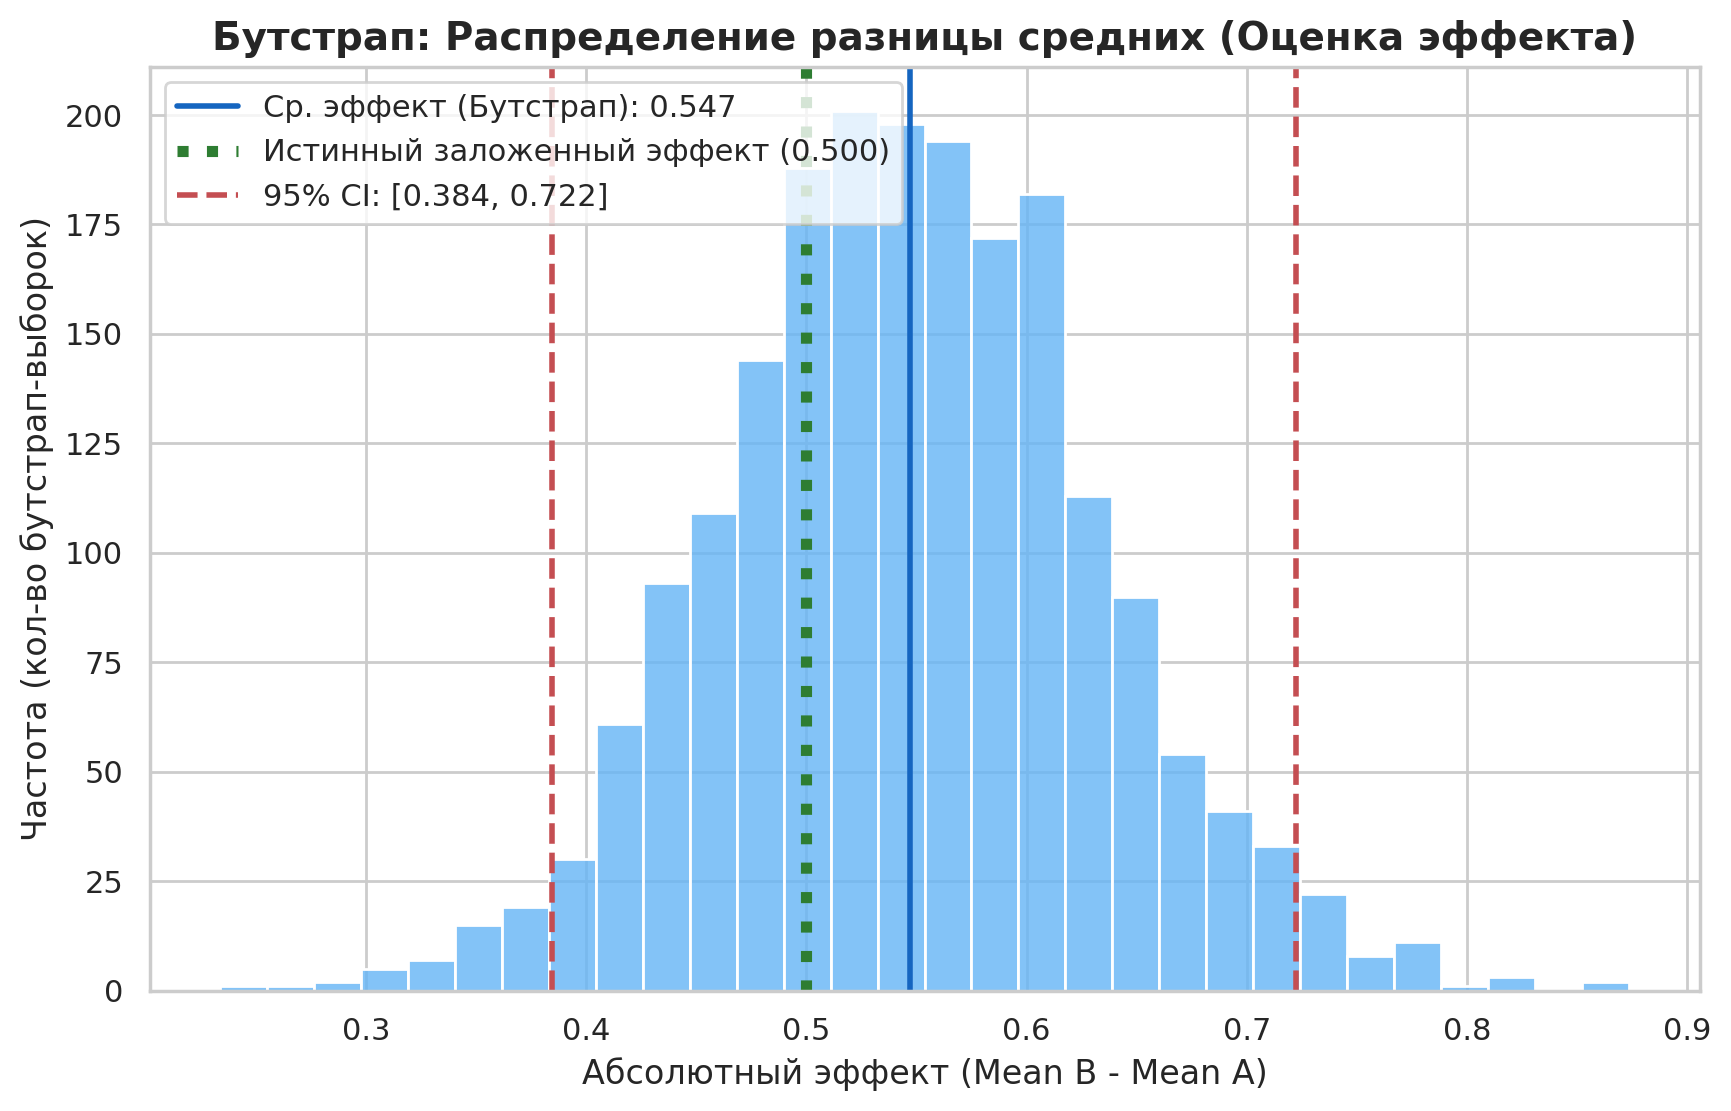

In [ ]:
# БУТСТРАП
# Генерируем результаты ОДНОГО эксперимента
N_experiment = 1000
A_prod = np.random.normal(10, 2, N_experiment)
B_prod = np.random.normal(10.5, 2, N_experiment) # Истинный заложенный эффект: +0.5


boot_sims = 2000
boot_effects = []

print("⏳ Сэмплируем данные через Бутстрап...")
for _ in range(boot_sims):
    # Выбираем случайные индексы с возвратом
    boot_A = np.random.choice(A_prod, size=N_experiment, replace=True)
    boot_B = np.random.choice(B_prod, size=N_experiment, replace=True)

    # Считаем разницу средних (эффект) в каждой виртуальной выборке
    effect = np.mean(boot_B) - np.mean(boot_A)
    boot_effects.append(effect)

# Расчет доверительных интервалов
ci_lower = np.percentile(boot_effects, 2.5)  # Нижняя граница (2.5%)
ci_upper = np.percentile(boot_effects, 97.5) # Верхняя граница (97.5%)
mean_boot_effect = np.mean(boot_effects)

# Визуализация распределения эффекта
plt.figure(figsize=(10, 6))
sns.histplot(boot_effects, bins=30, color='#64B5F6', alpha=0.8)

# Линии: Среднее по бутстрапу, Истинный эффект, Границы CI
plt.axvline(mean_boot_effect, color='#1565C0', linestyle='-', linewidth=2,
            label=f'Ср. эффект (Бутстрап): {mean_boot_effect:.3f}')
plt.axvline(0.5, color='#2E7D32', linestyle=':', linewidth=4,
            label='Истинный заложенный эффект (0.500)')
plt.axvline(ci_lower, color='#C44E52', linestyle='--', linewidth=2,
            label=f'95% CI: [{ci_lower:.3f}, {ci_upper:.3f}]')
plt.axvline(ci_upper, color='#C44E52', linestyle='--', linewidth=2)

plt.title('Бутстрап: Распределение разницы средних (Оценка эффекта)', fontsize=14, fontweight='bold')
plt.xlabel('Абсолютный эффект (Mean B - Mean A)')
plt.ylabel('Частота (кол-во бутстрап-выборок)')
plt.legend(loc='upper left')
plt.show()


⏳ Запуск  А/А теста с CUPED...


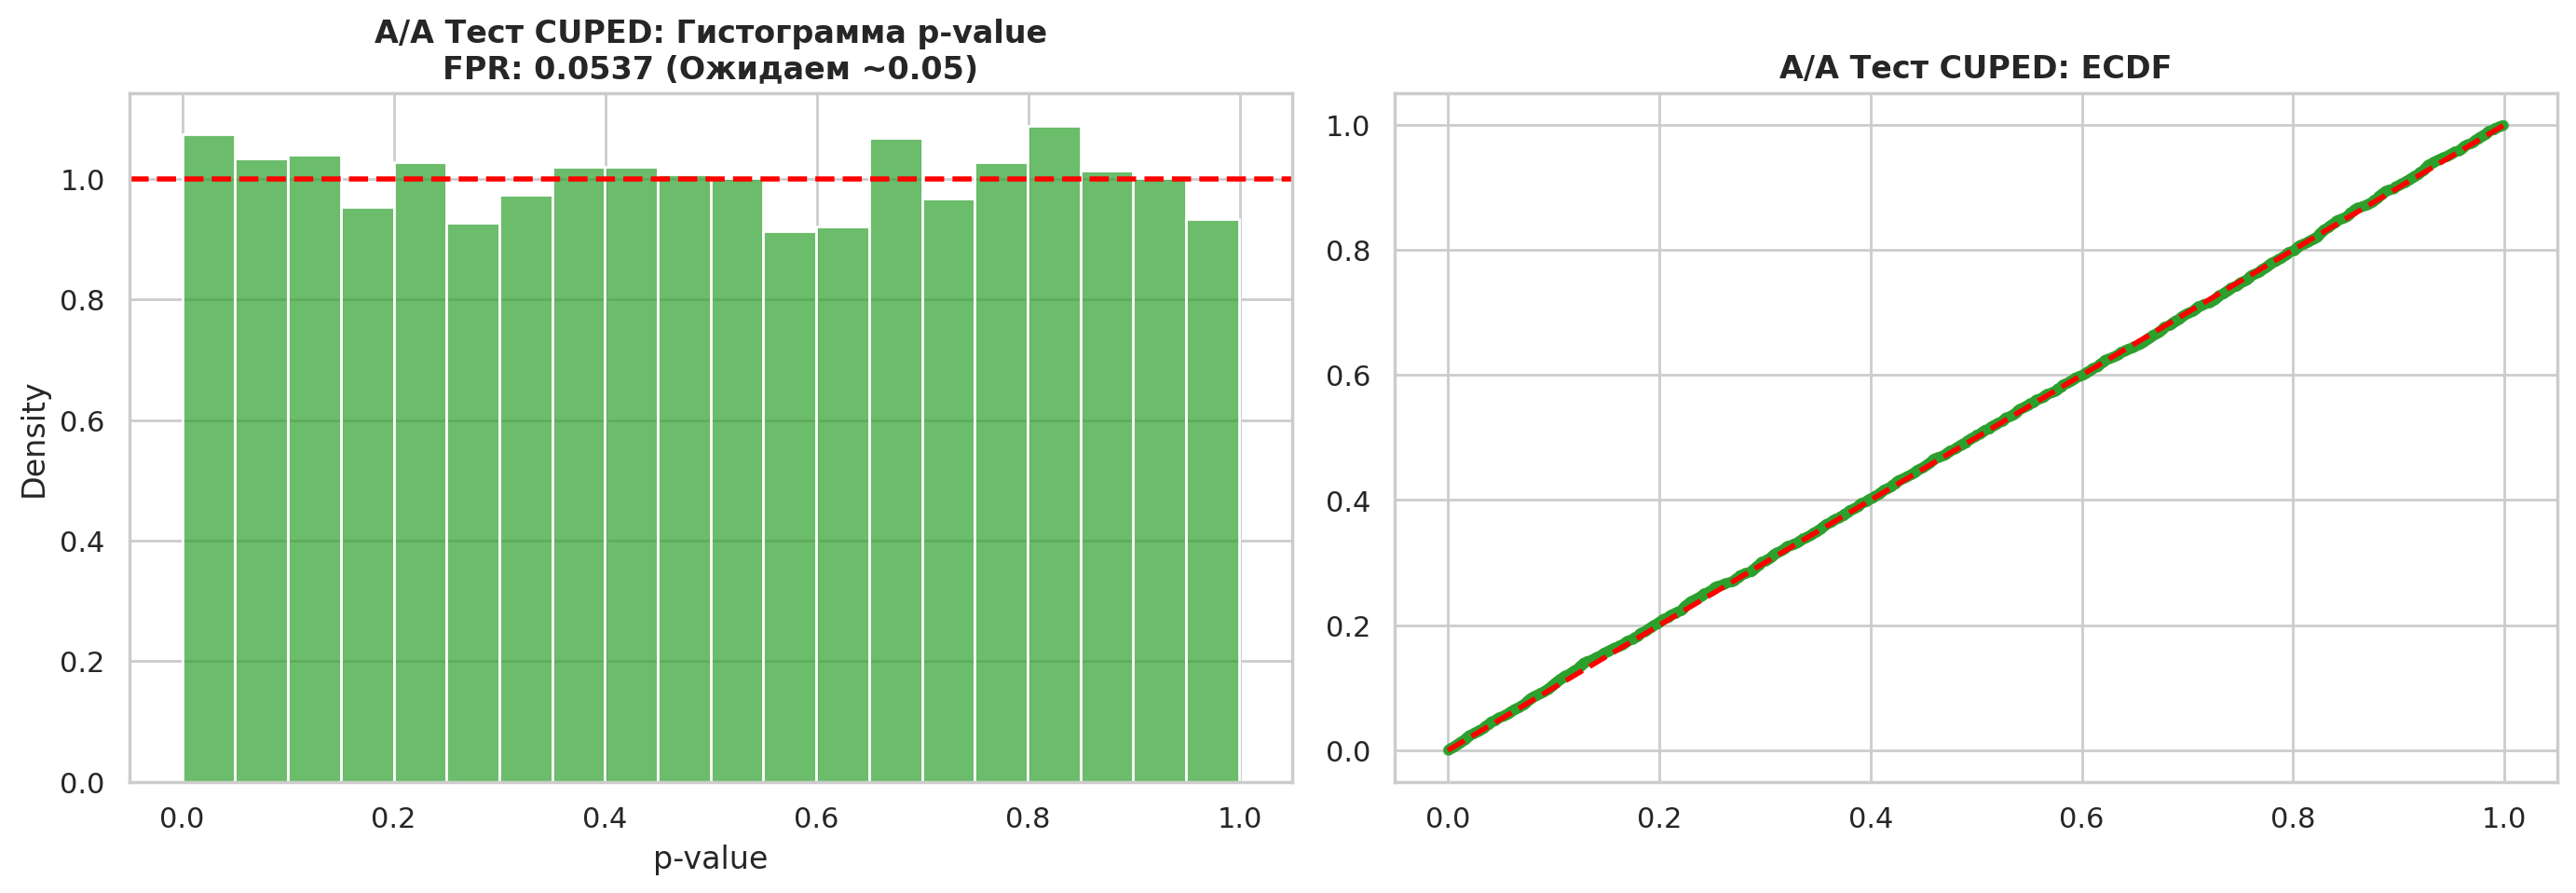

In [ ]:
# БАЗОВЫЙ CUPED И А/А ТЕСТ
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns

def generate_correlated_data(n, mu_X=10, mu_Y=10, std_X=2, std_Y=2, rho=0.6):
    """Генерирует ковариату (X) и метрику (Y) с заданной корреляцией rho"""
    cov_matrix = [[std_X**2, rho * std_X * std_Y],
                  [rho * std_X * std_Y, std_Y**2]]
    data = np.random.multivariate_normal([mu_X, mu_Y], cov_matrix, n)
    return data[:, 0], data[:, 1]

def apply_cuped_correctly(Y_A, Y_B, X_A, X_B):
    """Применяет ГЛОБАЛЬНЫЙ CUPED к обеим группам"""
    # Объединяем данные для поиска глобальных параметров (theta и среднее X)
    X_all = np.concatenate([X_A, X_B])
    Y_all = np.concatenate([Y_A, Y_B])

    # Считаем единый коэффициент theta
    theta = np.cov(Y_all, X_all)[0, 1] / np.var(X_all, ddof=1)

    # Считаем глобальное среднее ковариаты
    X_mean_global = np.mean(X_all)

    # Применяем ОДИНАКОВУЮ корректировку к обеим группам
    Y_cuped_A = Y_A - theta * (X_A - X_mean_global)
    Y_cuped_B = Y_B - theta * (X_B - X_mean_global)

    return Y_cuped_A, Y_cuped_B

n_sims_cuped = 3000
n_sample = 1000
alpha = 0.05
p_vals_cuped = []

print("⏳ Запуск  А/А теста с CUPED...")
for _ in range(n_sims_cuped):
    X_A, Y_A = generate_correlated_data(n_sample, rho=0.7)
    X_B, Y_B = generate_correlated_data(n_sample, rho=0.7)

    # Используем правильную функцию глобального расчета
    Y_cuped_A, Y_cuped_B = apply_cuped_correctly(Y_A, Y_B, X_A, X_B)

    # Сравниваем очищенные метрики
    _, p_val = stats.ttest_ind(Y_cuped_A, Y_cuped_B, equal_var=False)
    p_vals_cuped.append(p_val)

p_vals_cuped = np.array(p_vals_cuped)
fpr_cuped = np.mean(p_vals_cuped < alpha)

# Визуализация
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(p_vals_cuped, bins=20, stat='density', ax=axes[0], color='#2CA02C', alpha=0.7)
axes[0].axhline(1, color='red', linestyle='--', linewidth=2)
axes[0].set_title(f'А/А Тест CUPED: Гистограмма p-value\nFPR: {fpr_cuped:.4f} (Ожидаем ~0.05)', fontweight='bold')
axes[0].set_xlabel('p-value')

x = np.sort(p_vals_cuped)
y = np.arange(1, len(x) + 1) / len(x)
axes[1].plot(x, y, marker='.', linestyle='none', color='#2CA02C', alpha=0.5)
axes[1].plot([0, 1], [0, 1], color='red', linestyle='--', linewidth=2)
axes[1].set_title('А/А Тест CUPED: ECDF', fontweight='bold')

plt.tight_layout()
plt.show()

⚙️ Вычисленный множитель для N (вместо 16): 15.70
⏳ Запускаем симуляции с гибким расчетом...


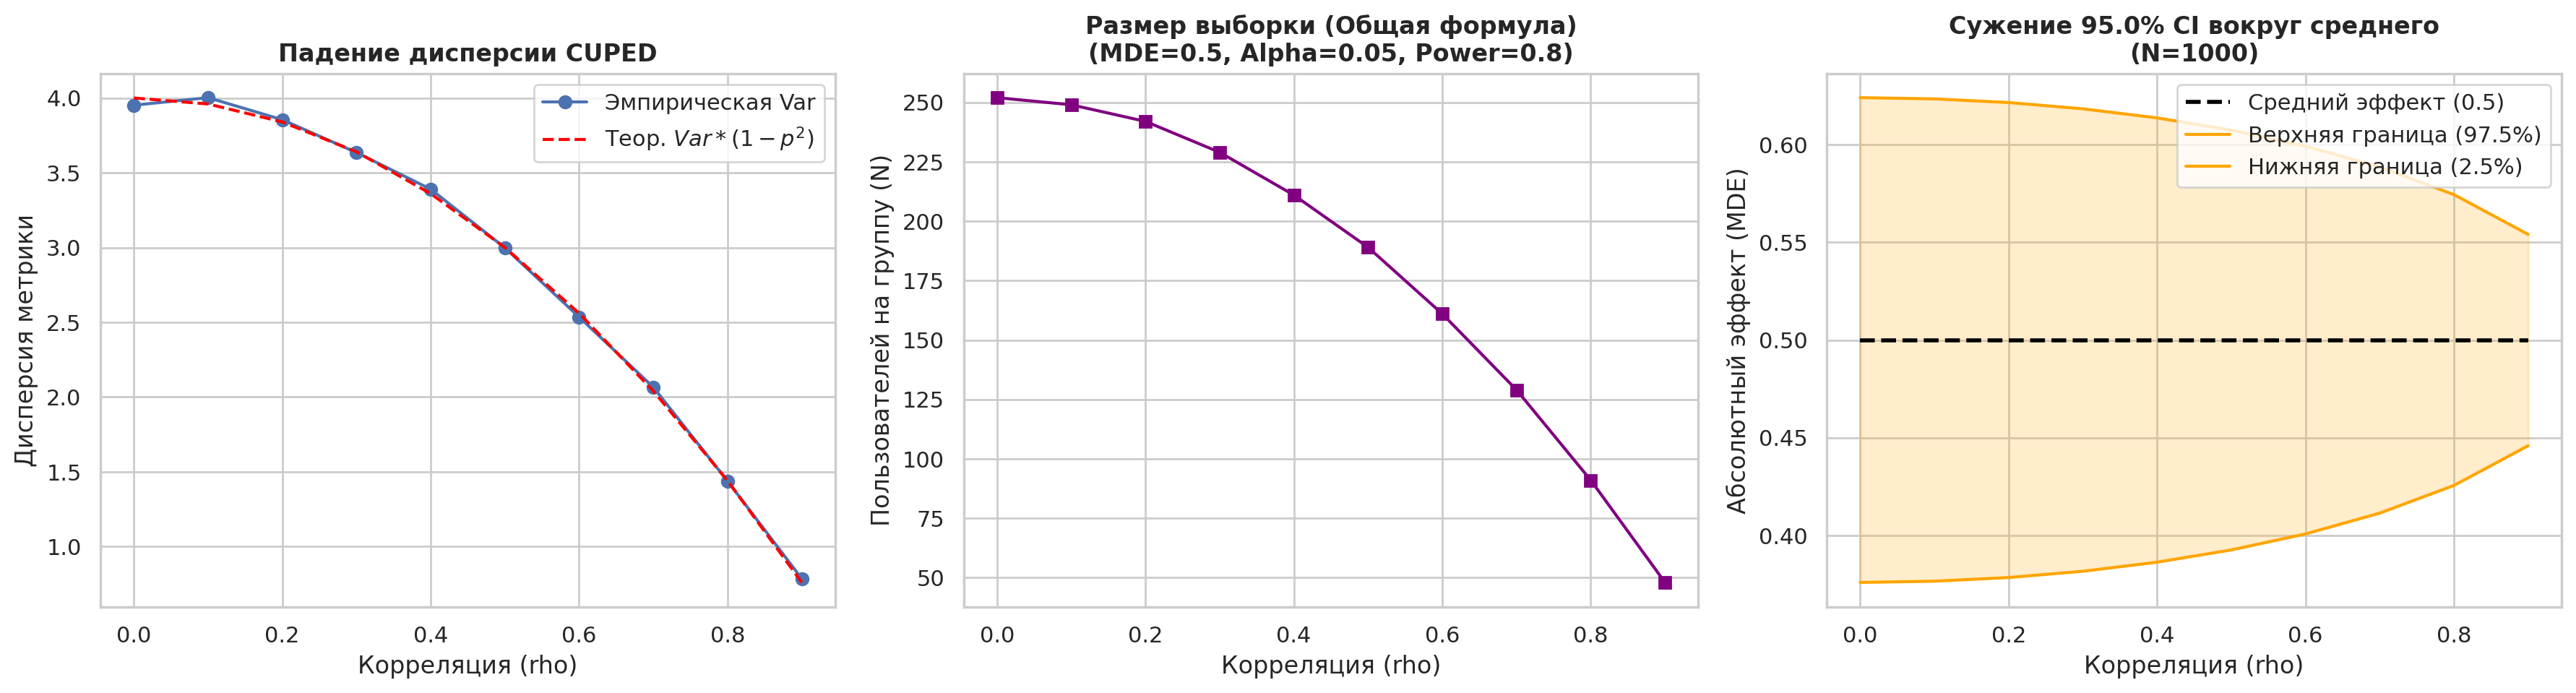

In [ ]:
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt

# Локальная функция одномерного CUPED
def apply_single_cuped(Y, X):
    theta = np.cov(Y, X)[0, 1] / np.var(X, ddof=1)
    return Y - theta * (X - np.mean(X))

# ПАРАМЕТРЫ ТЕСТА ---
alpha = 0.05   # Вероятность ошибки 1-го рода (5%)
power = 0.80   # Мощность теста (80%)
mde = 0.5      # Ожидаемый эффект
n_fixed = 1000 # Фиксированная выборка для расчета доверительного интервала

rhos = np.arange(0.0, 0.95, 0.1)
var_original = 2**2 # Исходная дисперсия

# Расчет множителя для выборки
z_alpha = stats.norm.ppf(1 - alpha / 2) # Для 0.05 вернет ~1.96
z_beta = stats.norm.ppf(power)          # Для 0.80 вернет ~0.84

# числитель общей формулы
n_multiplier = 2 * (z_alpha + z_beta)**2
print(f"⚙️ Вычисленный множитель для N (вместо 16): {n_multiplier:.2f}")

emp_variances = []
theor_variances = []
theor_sample_sizes = []

# Для графика доверительного интервала
ci_upper = []
ci_lower = []
ci_means = []

print("⏳ Запускаем симуляции с гибким расчетом...")
for r in rhos:
    # Расчет Дисперсии
    X, Y = generate_correlated_data(10000, std_Y=2, rho=r)
    Y_cuped = apply_single_cuped(Y, X)

    emp_variances.append(np.var(Y_cuped, ddof=1))

    # Теоретическая дисперсия CUPED
    var_c = var_original * (1 - r**2)
    theor_variances.append(var_c)

    # Необходимый размер выборки
    n_required = int(np.ceil((n_multiplier * var_c) / (mde**2)))
    theor_sample_sizes.append(n_required)

    # Расчет границ 95% доверительного интервала вокруг среднего эффекта
    ci_half_width = z_alpha * np.sqrt(var_c) / np.sqrt(n_fixed)
    ci_upper.append(mde + ci_half_width)
    ci_lower.append(mde - ci_half_width)
    ci_means.append(mde)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Дисперсия
axes[0].plot(rhos, emp_variances, marker='o', label='Эмпирическая Var')
axes[0].plot(rhos, theor_variances, linestyle='--', color='red', label='Теор. $Var * (1 - p^2)$')
axes[0].set_title('Падение дисперсии CUPED', fontweight='bold')
axes[0].set_xlabel('Корреляция (rho)')
axes[0].set_ylabel('Дисперсия метрики')
axes[0].legend()

# Размер выборки
axes[1].plot(rhos, theor_sample_sizes, marker='s', color='purple')
axes[1].set_title(f'Размер выборки (Общая формула)\n(MDE={mde}, Alpha={alpha}, Power={power})', fontweight='bold')
axes[1].set_xlabel('Корреляция (rho)')
axes[1].set_ylabel('Пользователей на группу (N)')

# Полноценный Доверительный Интервал
axes[2].plot(rhos, ci_means, color='black', linestyle='--', linewidth=2, label=f'Средний эффект ({mde})')
axes[2].plot(rhos, ci_upper, color='orange', label=f'Верхняя граница ({(1-alpha/2)*100}%)')
axes[2].plot(rhos, ci_lower, color='orange', label=f'Нижняя граница ({(alpha/2)*100}%)')
axes[2].fill_between(rhos, ci_lower, ci_upper, color='orange', alpha=0.2)

axes[2].set_title(f'Сужение {(1-alpha)*100}% CI вокруг среднего\n(N={n_fixed})', fontweight='bold')
axes[2].set_xlabel('Корреляция (rho)')
axes[2].set_ylabel('Абсолютный эффект (MDE)')
axes[2].legend(loc='upper right')

plt.tight_layout()
plt.show()

📊 Сравнение дисперсии (Var):
Исходная Y: 3.9512
Независимый Multi-CUPED: 2.7960
Итеративный Multi-CUPED: 2.4158

⏳ Запуск А/А тестов для Multi-CUPED...


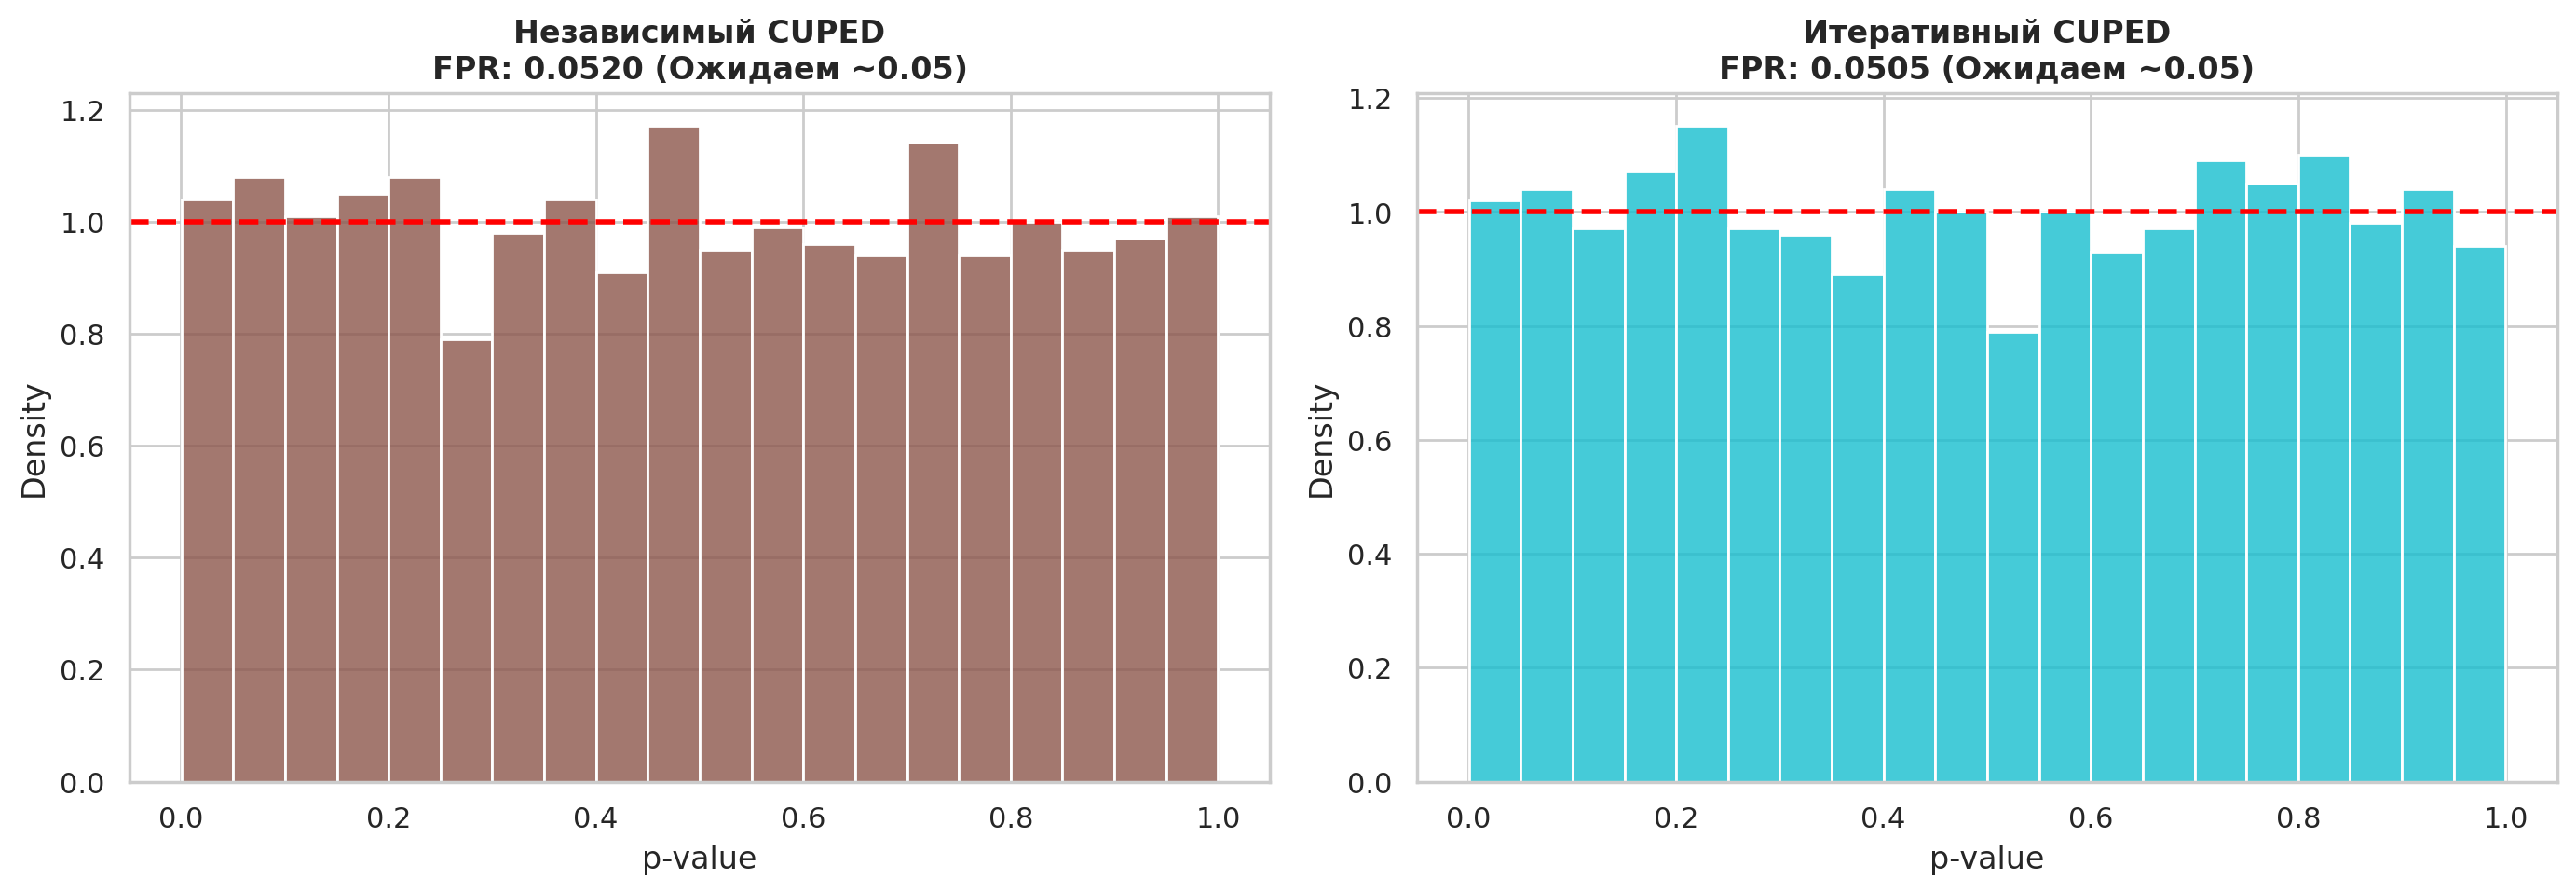

In [ ]:
# MULTI-CUPED
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns

def generate_multi_covariates(n):
    """Генерирует Y (метрику) и две ковариаты X1 (сильная), X2 (слабая)"""
    cov_matrix = [
        [4.0, 2.5, 1.5], # Y
        [2.5, 4.0, 2.0], # X1
        [1.5, 2.0, 4.0]  # X2
    ]
    data = np.random.multivariate_normal([10, 10, 10], cov_matrix, n)
    return data[:, 0], data[:, 1], data[:, 2]

def apply_multi_cuped_ind_global(Y_A, Y_B, X1_A, X1_B, X2_A, X2_B):
    """Глобальный Независимый Multi-CUPED"""
    # Объединяем данные
    Y_all = np.concatenate([Y_A, Y_B])
    X1_all = np.concatenate([X1_A, X1_B])
    X2_all = np.concatenate([X2_A, X2_B])

    # Считаем глобальные параметры
    theta1 = np.cov(Y_all, X1_all)[0, 1] / np.var(X1_all, ddof=1)
    theta2 = np.cov(Y_all, X2_all)[0, 1] / np.var(X2_all, ddof=1)

    X1_mean_global = np.mean(X1_all)
    X2_mean_global = np.mean(X2_all)

    # Применяем единую корректировку
    Y_ind_A = Y_A - theta1 * (X1_A - X1_mean_global) - theta2 * (X2_A - X2_mean_global)
    Y_ind_B = Y_B - theta1 * (X1_B - X1_mean_global) - theta2 * (X2_B - X2_mean_global)
    return Y_ind_A, Y_ind_B

def apply_multi_cuped_iter_global(Y_A, Y_B, X1_A, X1_B, X2_A, X2_B):
    """Глобальный Итеративный Multi-CUPED"""
    Y_all = np.concatenate([Y_A, Y_B])
    X1_all = np.concatenate([X1_A, X1_B])
    X2_all = np.concatenate([X2_A, X2_B])

    # Первая ковариата (X1)
    theta1 = np.cov(Y_all, X1_all)[0, 1] / np.var(X1_all, ddof=1)
    X1_mean_global = np.mean(X1_all)

    Y_step1_A = Y_A - theta1 * (X1_A - X1_mean_global)
    Y_step1_B = Y_B - theta1 * (X1_B - X1_mean_global)

    # Обновляем объединенный массив для
    Y_step1_all = np.concatenate([Y_step1_A, Y_step1_B])

    #Вторая ковариата (X2) применяется к метрике
    theta2 = np.cov(Y_step1_all, X2_all)[0, 1] / np.var(X2_all, ddof=1)
    X2_mean_global = np.mean(X2_all)

    Y_iter_A = Y_step1_A - theta2 * (X2_A - X2_mean_global)
    Y_iter_B = Y_step1_B - theta2 * (X2_B - X2_mean_global)

    return Y_iter_A, Y_iter_B

# Сравнение Дисперсий
Y_raw_A, X1_A, X2_A = generate_multi_covariates(5000)
Y_raw_B, X1_B, X2_B = generate_multi_covariates(5000)

Y_ind_A, Y_ind_B = apply_multi_cuped_ind_global(Y_raw_A, Y_raw_B, X1_A, X1_B, X2_A, X2_B)
Y_iter_A, Y_iter_B = apply_multi_cuped_iter_global(Y_raw_A, Y_raw_B, X1_A, X1_B, X2_A, X2_B)

var_raw = np.var(np.concatenate([Y_raw_A, Y_raw_B]), ddof=1)
var_ind = np.var(np.concatenate([Y_ind_A, Y_ind_B]), ddof=1)
var_iter = np.var(np.concatenate([Y_iter_A, Y_iter_B]), ddof=1)

print(f"📊 Сравнение дисперсии (Var):")
print(f"Исходная Y: {var_raw:.4f}")
print(f"Независимый Multi-CUPED: {var_ind:.4f}")
print(f"Итеративный Multi-CUPED: {var_iter:.4f}\n")

# А/А Тест (Симуляция Монте-Карло)
p_vals_ind, p_vals_iter = [], []
print("⏳ Запуск А/А тестов для Multi-CUPED...")

n_sims_multi = 2000
for _ in range(n_sims_multi):
    Y_A, X1_A, X2_A = generate_multi_covariates(500)
    Y_B, X1_B, X2_B = generate_multi_covariates(500)

    # Независимый глобальный
    Y_i_A, Y_i_B = apply_multi_cuped_ind_global(Y_A, Y_B, X1_A, X1_B, X2_A, X2_B)
    p_vals_ind.append(stats.ttest_ind(Y_i_A, Y_i_B, equal_var=False)[1])

    # Итеративный глобальный
    Y_it_A, Y_it_B = apply_multi_cuped_iter_global(Y_A, Y_B, X1_A, X1_B, X2_A, X2_B)
    p_vals_iter.append(stats.ttest_ind(Y_it_A, Y_it_B, equal_var=False)[1])

fpr_ind = np.mean(np.array(p_vals_ind) < 0.05)
fpr_iter = np.mean(np.array(p_vals_iter) < 0.05)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(p_vals_ind, bins=20, stat='density', ax=axes[0], color='#8C564B', alpha=0.8)
axes[0].axhline(1, color='red', linestyle='--', linewidth=2)
axes[0].set_title(f'Независимый CUPED\nFPR: {fpr_ind:.4f} (Ожидаем ~0.05)', fontweight='bold')
axes[0].set_xlabel('p-value')

sns.histplot(p_vals_iter, bins=20, stat='density', ax=axes[1], color='#17BECF', alpha=0.8)
axes[1].axhline(1, color='red', linestyle='--', linewidth=2)
axes[1].set_title(f'Итеративный CUPED\nFPR: {fpr_iter:.4f} (Ожидаем ~0.05)', fontweight='bold')
axes[1].set_xlabel('p-value')

plt.tight_layout()
plt.show()